# Lid-driven cavity flow

## Import Library

In [226]:
import numpy as np
import matplotlib.pyplot as plt

## Domain Setup

In [227]:
L = 1.0  # Length of the cavity
N = 41   # Number of grid points

dx = 0.025  # Grid spacing
dy = 0.025

Re = 100.0  # Reynolds number
U_lid = 1.0  # Lid velocity

Nu = U_lid * L / Re  # Kinematic viscosity

# Initial velocity and pressure fields
u = np.zeros((N, N)) 
v = np.zeros((N, N))
p = np.zeros((N, N))

x = np.linspace(0, L, N)
y = np.linspace(0, L, N)
X, Y = np.meshgrid(x, y)

safety_factor = 0.8

dt = safety_factor / (U_lid/dx + U_lid/dy + 4*Nu/dx**2)

CFL_x = U_lid * dt / dx
CFL_y = U_lid * dt / dy
r = Nu * dt / dx**2

print(f"dt       = {dt:.6f}")
print(f"CFL_x    = {CFL_x:.4f}")
print(f"CFL_y    = {CFL_y:.4f}")
print(f"r        = {r:.4f}")
print(f"Combined = {CFL_x + CFL_y + 4*r:.4f}  (must be ≤ 1)")

nt = 20000  # Number of time steps
T = nt * dt  # Total simulation time
print(f"Total simulation time T = {T:.4f}")

dt       = 0.005556
CFL_x    = 0.2222
CFL_y    = 0.2222
r        = 0.0889
Combined = 0.8000  (must be ≤ 1)
Total simulation time T = 111.1111


## Algorithm Per Time Step

## Apply boundary conditions to u, v

In [228]:
def apply_boundary_conditions(u, v):
    # Top lid — moves right at U_lid, no vertical velocity
    u[-1, :] = U_lid
    v[-1, :] = 0.0

    # bottom
    u[0,:]=0.0
    v[0,:]=0.0
    
    # left
    u[:,0]=0.0
    v[:,0]=0.0

    # right
    u[:,-1]=0.0
    v[:,-1]=0.0

    return u, v

## Momentum Predictor - Compute u*, v* (momentum without pressure)

In [229]:
def momentum_predictor(u, v, p, dx, dy, dt, Nu):
    un = u.copy()
    vn = v.copy()

    u_star = un.copy()
    v_star = vn.copy()

    # Neighbours of u, v - interior points only
    u_e = un[1:-1, 2:]   # u[i, j+1]
    u_w = un[1:-1, :-2]  # u[i, j-1]
    u_n = un[2:, 1:-1]   # u[i+1, j]
    u_s = un[:-2, 1:-1]  # u[i-1, j]

    v_e = vn[1:-1, 2:]   # v[i, j+1]
    v_w = vn[1:-1, :-2]  # v[i, j-1]
    v_n = vn[2:, 1:-1]   # v[i+1, j]
    v_s = vn[:-2, 1:-1]  # v[i-1, j]

    # Convection terms - Upwind scheme
    conv_u_x = np.maximum(un[1:-1, 1:-1], 0) * (un[1:-1, 1:-1] - u_w)/dx + np.minimum(un[1:-1, 1:-1], 0) * (u_e - un[1:-1, 1:-1])/dx
    conv_u_y = np.maximum(vn[1:-1, 1:-1], 0) * (un[1:-1, 1:-1] - u_s)/dy + np.minimum(vn[1:-1, 1:-1], 0) * (u_n - un[1:-1, 1:-1])/dy
    
    conv_v_x = np.maximum(un[1:-1, 1:-1], 0) * (vn[1:-1, 1:-1] - v_w)/dx + np.minimum(un[1:-1, 1:-1], 0) * (v_e - vn[1:-1, 1:-1])/dx
    conv_v_y = np.maximum(vn[1:-1, 1:-1], 0) * (vn[1:-1, 1:-1] - v_s)/dy + np.minimum(vn[1:-1, 1:-1], 0) * (v_n - vn[1:-1, 1:-1])/dy

    conv_u = conv_u_x + conv_u_y
    conv_v = conv_v_x + conv_v_y

    # Diffusion terms (central differences)
    diff_u = Nu * (u_e - 2*un[1:-1, 1:-1] + u_w) / dx**2 + Nu * (u_n - 2*un[1:-1, 1:-1] + u_s) / dy**2
    diff_v = Nu * (v_n - 2*vn[1:-1, 1:-1] + v_s) / dy**2 + Nu * (v_e - 2*vn[1:-1, 1:-1] + v_w) / dx**2

    u_star[1:-1, 1:-1] = un[1:-1, 1:-1] + dt * (diff_u - conv_u)
    v_star[1:-1, 1:-1] = vn[1:-1, 1:-1] + dt * (diff_v - conv_v)

    return u_star, v_star

## Compute divergence b = ∇·u*

In [230]:
# compute the divergence of the intermediate velocity field
def compute_divergence(u_star, v_star, dx, dy):
    div = (u_star[1:-1, 2:] - u_star[1:-1, :-2]) / (2*dx) + (v_star[2:, 1:-1] - v_star[:-2, 1:-1]) / (2*dy)
    return div

## Connector - Pressure Poisson Solver

In [231]:
def pressure_poisson_connector(u_star, v_star, p, dx, dy, dt, rho=1.0, max_iter=20000, tol=1e-4):
    # Solve the Poisson equation iteratively
    for it in range(max_iter):
        p_old = p.copy()

        # Neighbours of p - interior points only
        p_e = p_old[1:-1, 2:]   # p[i, j+1]
        p_w = p_old[1:-1, :-2]  # p[i, j-1]
        p_n = p_old[2:, 1:-1]   # p[i+1, j]
        p_s = p_old[:-2, 1:-1]  # p[i-1, j]

        div = compute_divergence(u_star, v_star, dx, dy)

        rhs = (rho / dt) * div

        # Jacobi update for pressure
        p[1:-1, 1:-1] = (p_e + p_w) * dy**2 + (p_n + p_s) * dx**2 - rhs * dx**2 * dy**2
        p[1:-1, 1:-1] /= (2 * (dx**2 + dy**2))

        # Boundary conditions for pressure (Neumann: dp/dn=0)
        p[0, :] = p[1, :]     # dp/dy=0 at bottom
        p[-1, :] = p[-2, :]   # dp/dy=0 at top
        p[:, 0] = p[:, 1]     # dp/dx=0 at left
        p[:, -1] = p[:, -2]   # dp/dx=0 at right

        p[1, 1] = 0.0  # Reference pressure point to avoid singularity

        # Check for convergence
        if np.linalg.norm(p - p_old) < tol:
            break
    else:
        print("Pressure Poisson did not converge within the maximum iterations.")
    
    return p

## Correct: u = u* - dt·∂p/∂x,  v = v* - dt·∂p/∂y

In [232]:
def velocity_corrector(u_star, v_star, p, dx, dy, dt, rho=1.0):
    u = u_star.copy()
    v = v_star.copy()

    # Neighbours of p - interior points only
    p_e = p[1:-1, 2:]   # p[i, j+1]
    p_w = p[1:-1, :-2]  # p[i, j-1]
    p_n = p[2:, 1:-1]   # p[i+1, j]
    p_s = p[:-2, 1:-1]  # p[i-1, j]

    u[1:-1, 1:-1] = u_star[1:-1, 1:-1] - (dt/rho) * (p_e - p_w) / (2*dx)
    v[1:-1, 1:-1] = v_star[1:-1, 1:-1] - (dt/rho) * (p_n - p_s) / (2*dy)

    return u, v

## Track ${max|u^{n+1} - u^n|}$ for steady state convergence

In [233]:
def check_convergence(u, v, u_old, v_old, tol=1e-4):
    du = np.linalg.norm(u - u_old)
    dv = np.linalg.norm(v - v_old)
    return du < tol and dv < tol

## Main Loop

In [234]:
residual_history = []
u_history = []
v_history = []
p_history = []

for n in range(nt):
    u_old = u.copy()
    v_old = v.copy()
    p_old = p.copy()

    u_old, v_old = apply_boundary_conditions(u_old, v_old)
    u_star, v_star = momentum_predictor(u_old, v_old, p_old, dx, dy, dt, Nu)
    p = pressure_poisson_connector(u_star, v_star, p_old, dx, dy, dt)
    u, v = velocity_corrector(u_star, v_star, p, dx, dy, dt)

    u, v = apply_boundary_conditions(u, v)

    u_history.append(u.copy())
    v_history.append(v.copy())
    p_history.append(p.copy())

    residual = np.max(np.abs(u - u_old))
    residual_history.append(residual)
    if n % 100 == 0:
        print(f"Step {n:4d} | residual = {residual:.2e}")
        
    if check_convergence(u, v, u_old, v_old):
        print(f"Converged at step {n}.")
        break

else:    print("Did not converge within the maximum time steps.")

Step    0 | residual = 8.66e-02
Step  100 | residual = 1.94e-03
Step  200 | residual = 7.76e-04
Step  300 | residual = 4.05e-04
Step  400 | residual = 2.42e-04
Step  500 | residual = 1.55e-04
Step  600 | residual = 1.04e-04
Step  700 | residual = 7.10e-05
Step  800 | residual = 4.95e-05
Step  900 | residual = 3.48e-05
Step 1000 | residual = 2.46e-05
Step 1100 | residual = 1.75e-05
Step 1200 | residual = 1.25e-05
Step 1300 | residual = 8.88e-06
Step 1400 | residual = 6.34e-06
Converged at step 1428.


## Result Visualization

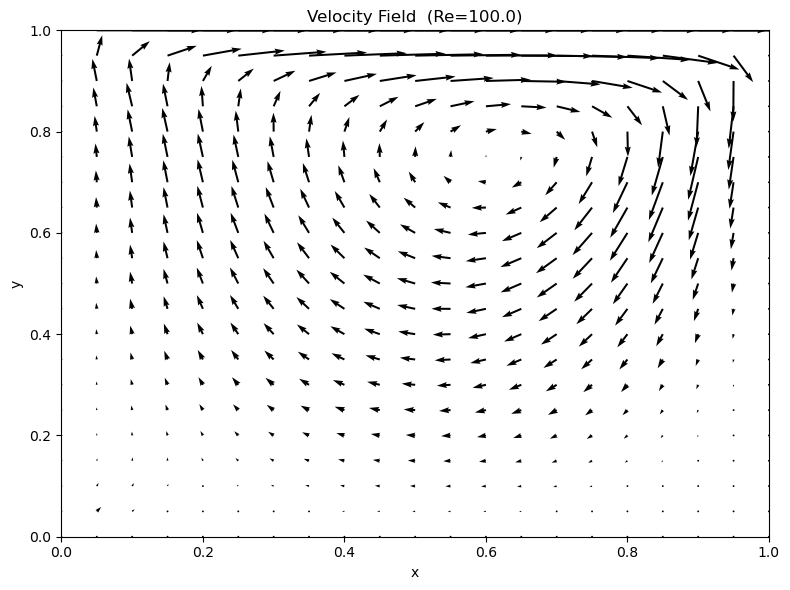

In [235]:
# Velocity Field — subsampled quiver
step = 2
plt.figure(figsize=(8, 6))
plt.title(f"Velocity Field  (Re={Re})")
plt.quiver(X[::step, ::step], Y[::step, ::step],
           u[::step, ::step], v[::step, ::step])
plt.xlabel('x'); plt.ylabel('y')
plt.xlim(0, L); plt.ylim(0, L)
plt.tight_layout()
plt.show()

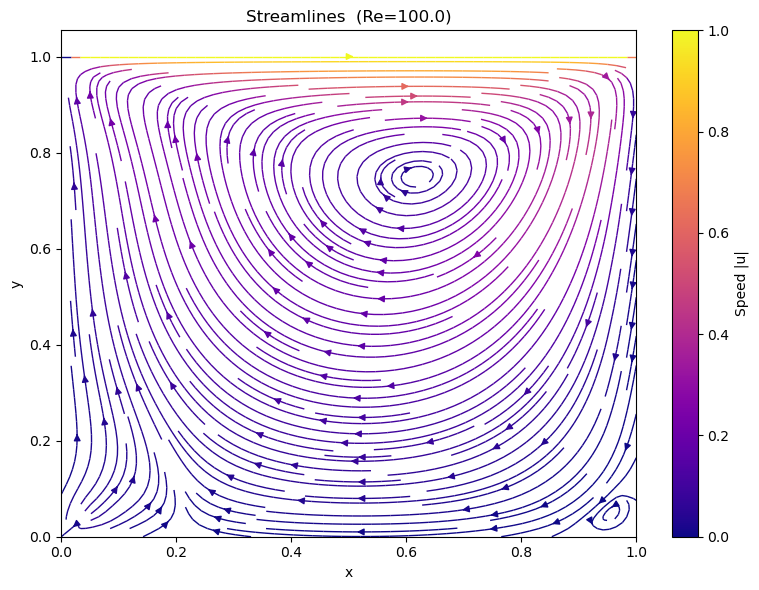

In [236]:
# Streamlines — primary vortex and corner vortices
speed = np.sqrt(u**2 + v**2)
plt.figure(figsize=(8, 6))
plt.title(f"Streamlines  (Re={Re})")
plt.streamplot(x, y, u, v, density=2, color=speed, cmap='plasma', linewidth=1)
plt.colorbar(label='Speed |u|')
plt.xlabel('x'); plt.ylabel('y')
plt.tight_layout()
plt.show()

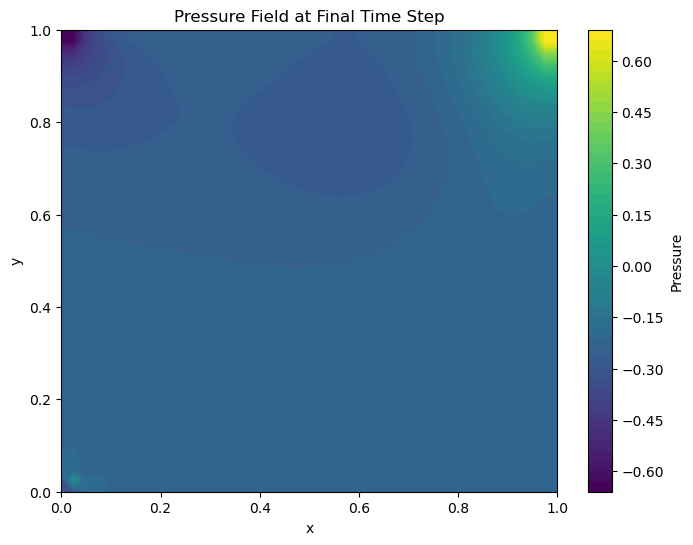

In [237]:
# Pressure Field Visualization
plt.figure(figsize=(8, 6))
plt.title("Pressure Field at Final Time Step")
plt.contourf(X, Y, p, levels=50, cmap='viridis')
plt.colorbar(label='Pressure')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(0, L)
plt.ylim(0, L)
plt.show()

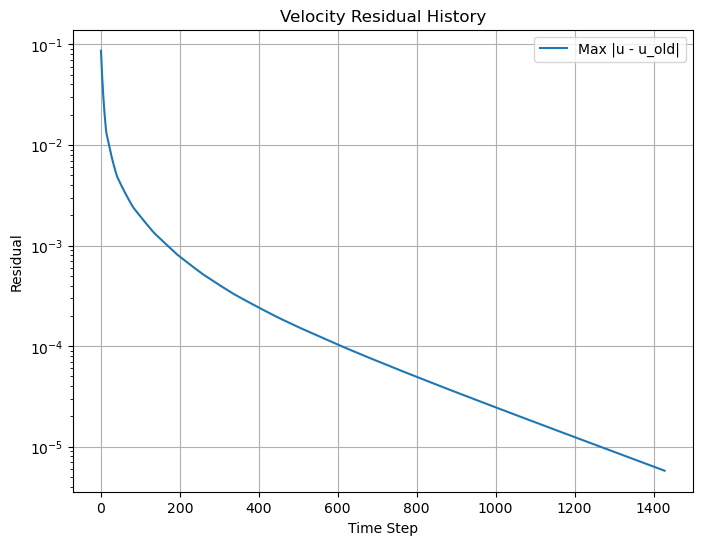

In [238]:
# Velocity Residual Plot
plt.figure(figsize=(8, 6))
plt.title("Velocity Residual History")
plt.semilogy(residual_history, label='Max |u - u_old|')
plt.xlabel('Time Step')
plt.ylabel('Residual')
plt.grid()
plt.legend()
plt.show()

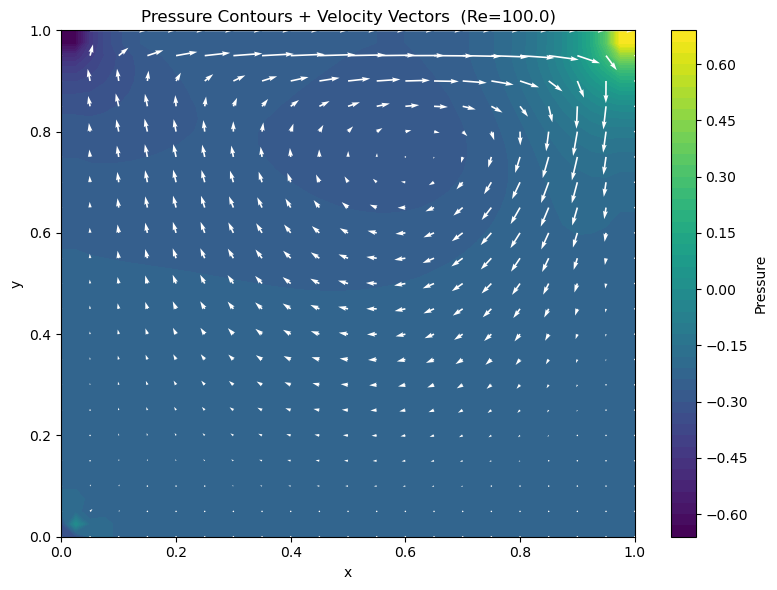

In [239]:
# Pressure contours + subsampled velocity vectors
step = 2
plt.figure(figsize=(8, 6))
plt.title(f"Pressure Contours + Velocity Vectors  (Re={Re})")
plt.contourf(X, Y, p, levels=50, cmap='viridis')
plt.colorbar(label='Pressure')
plt.quiver(X[::step, ::step], Y[::step, ::step],
           u[::step, ::step], v[::step, ::step],
           color='white', scale=10)
plt.xlabel('x'); plt.ylabel('y')
plt.tight_layout()
plt.show()

## Validation: Ghia et al. (1982) Benchmark

Compare centerline velocity profiles against the landmark paper:
**Ghia, Ghia & Shin (1982)** — *High-Re solutions for incompressible flow using the Navier-Stokes equations and a multigrid method*

- **u along x = 0.5** (vertical centerline): captures primary vortex strength
- **v along y = 0.5** (horizontal centerline): captures left/right recirculation

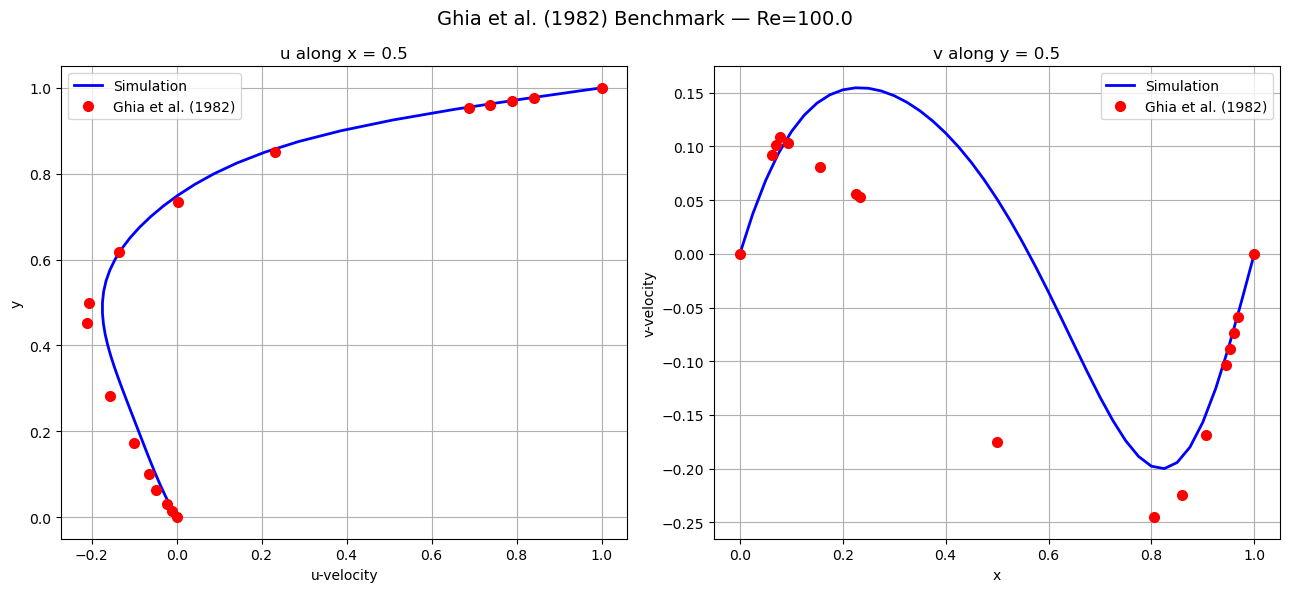

In [240]:
# Ghia et al. (1982) Re=100 benchmark data
ghia_y = [0.0000, 0.0156, 0.0313, 0.0625, 0.1016, 0.1719, 0.2813, 0.4531,
          0.5000, 0.6172, 0.7344, 0.8516, 0.9531, 0.9609, 0.9688, 0.9766, 1.0000]
ghia_u = [0.00000, -0.01160, -0.02347, -0.04775, -0.06434, -0.10150, -0.15662, -0.21090,
          -0.20581, -0.13641,  0.00332,  0.23151,  0.68717,  0.73722,  0.78871,  0.84123, 1.00000]

ghia_x = [0.0000, 0.0625, 0.0703, 0.0781, 0.0938, 0.1563, 0.2266, 0.2344,
          0.5000, 0.8047, 0.8594, 0.9063, 0.9453, 0.9531, 0.9609, 0.9688, 1.0000]
ghia_v = [0.00000,  0.09233,  0.10091,  0.10890,  0.10313,  0.08066,  0.05602,  0.05334,
         -0.17527, -0.24533, -0.22445, -0.16914, -0.10313, -0.08864, -0.07391, -0.05906, 0.00000]

mid = N // 2  # index 20 -> x=0.5, y=0.5

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle(f"Ghia et al. (1982) Benchmark — Re={Re}", fontsize=14)

# u along vertical centerline (x = 0.5)
ax1.plot(u[:, mid], y, "-b", linewidth=2, label="Simulation")
ax1.plot(ghia_u, ghia_y, "ro", markersize=7, label="Ghia et al. (1982)")
ax1.set_xlabel("u-velocity"); ax1.set_ylabel("y")
ax1.set_title("u along x = 0.5")
ax1.legend(); ax1.grid(True)

# v along horizontal centerline (y = 0.5)
ax2.plot(x, v[mid, :], "-b", linewidth=2, label="Simulation")
ax2.plot(ghia_x, ghia_v, "ro", markersize=7, label="Ghia et al. (1982)")
ax2.set_xlabel("x"); ax2.set_ylabel("v-velocity")
ax2.set_title("v along y = 0.5")
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()

## Pressure contours + subsampled velocity vectors with time scale

In [241]:
import plotly.graph_objects as go
import plotly.figure_factory as ff
import numpy as np

step = 2
n_frames = 25
snap_steps = [int(round(i * (len(p_history) - 1) / (n_frames - 1))) for i in range(n_frames)]

X_s = X[::step, ::step]
Y_s = Y[::step, ::step]
xs = X_s.flatten()
ys = Y_s.flatten()

def make_hover_trace(n):
    us = u_history[n][::step, ::step].flatten()
    vs = v_history[n][::step, ::step].flatten()
    # Interpolate pressure onto the subsampled grid
    from scipy.interpolate import RegularGridInterpolator
    interp = RegularGridInterpolator((y, x), p_history[n], method='linear')
    ps = interp(np.column_stack([ys, xs]))

    return go.Scatter(
        x=xs,
        y=ys,
        mode='markers',
        marker=dict(size=6, opacity=0),   # invisible markers
        hovertemplate=(
            'x: %{x:.3f}<br>'
            'y: %{y:.3f}<br>'
            'u: %{customdata[0]:.4f}<br>'
            'v: %{customdata[1]:.4f}<br>'
            'p: %{customdata[2]:.4f}<extra></extra>'
        ),
        customdata=np.column_stack([us, vs, ps]),
        name='Values',
        showlegend=False
    )

def make_quiver_trace(n):
    us = u_history[n][::step, ::step].flatten()
    vs = v_history[n][::step, ::step].flatten()
    qf = ff.create_quiver(xs, ys, us, vs, scale=0.1, arrow_scale=0.3,
                           line=dict(color='white', width=1))
    qt = qf.data[0]
    return go.Scatter(
        x=qt.x, y=qt.y,
        mode='lines',
        line=dict(color='white', width=1),
        name='Velocity',
        hoverinfo='skip'
    )

# Build frames
frames = []
for n in snap_steps:
    frames.append(go.Frame(
        data=[
            go.Contour(
                z=p_history[n],
                x=x, y=y,
                colorscale='Viridis',
                contours=dict(showlabels=True, labelfont_size=10),
                colorbar=dict(title='Pressure'),
                hoverinfo='skip'
            ),
            make_quiver_trace(n),
            make_hover_trace(n)
        ],
        name=str(n)
    ))

# Initial figure
fig = go.Figure(
    data=[
        go.Contour(
            z=p_history[0],
            x=x, y=y,
            colorscale='Viridis',
            contours=dict(showlabels=True, labelfont_size=10),
            colorbar=dict(title='Pressure'),
            hoverinfo='skip'
        ),
        make_quiver_trace(0),
        make_hover_trace(0)
    ],
    frames=frames
)

slider_steps = [
    dict(
        method='animate',
        args=[[str(n)], dict(mode='immediate', frame=dict(duration=0), transition=dict(duration=0))],
        label=f'{n * dt:.3f} s'
    )
    for n in snap_steps
]

fig.update_layout(
    title=dict(text='Pressure Contours + Velocity Vectors', x=0.5),
    xaxis_title='x',
    yaxis_title='y',
    xaxis=dict(range=[0, L]),
    yaxis=dict(range=[0, L]),
    plot_bgcolor='black',
    width=750, height=650,
    sliders=[dict(
        active=0,
        currentvalue=dict(prefix='Time: ', visible=True, xanchor='center'),
        pad=dict(t=50),
        steps=slider_steps
    )]
)

fig.show()

In [242]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display

# ── create the figure widget once ────────────────────────────────────────────
fig = go.FigureWidget(make_subplots(
    rows=2, cols=3,
    subplot_titles=[
        'p along y=?', 'u along y=?', 'v along y=?',
        'p along x=?', 'u along x=?', 'v along x=?',
    ],
    horizontal_spacing=0.1, vertical_spacing=0.15
))

# add all 6 traces once (we'll update their data in place)
for col in range(1, 4):
    fig.add_trace(go.Scatter(mode='lines', line=dict(width=2)), row=1, col=col)
for col in range(1, 4):
    fig.add_trace(go.Scatter(mode='lines', line=dict(width=2)), row=2, col=col)

fig.update_layout(
    height=500, width=900,
    showlegend=False,
    margin=dict(t=80, b=40)
)
for col in range(1, 4):
    fig.update_xaxes(title_text='x', row=1, col=col)
    fig.update_xaxes(title_text='y', row=2, col=col)

# ── widgets ───────────────────────────────────────────────────────────────────
t_slider = widgets.IntSlider(
    value=0, min=0, max=len(p_history)-1, step=1,
    description='Time step:', style={'description_width': '100px'},
    layout=widgets.Layout(width='600px')
)
x_slider = widgets.FloatSlider(
    value=float(x[len(x)//2]), min=float(x[0]), max=float(x[-1]),
    step=float(x[1]-x[0]), description='x slice:',
    style={'description_width': '100px'}, layout=widgets.Layout(width='600px'),
    readout_format='.3f'
)
y_slider = widgets.FloatSlider(
    value=float(y[len(y)//2]), min=float(y[0]), max=float(y[-1]),
    step=float(y[1]-y[0]), description='y slice:',
    style={'description_width': '100px'}, layout=widgets.Layout(width='600px'),
    readout_format='.3f'
)

def update(change=None):
    n     = t_slider.value
    x_val = x_slider.value
    y_val = y_slider.value

    xi = int(np.argmin(np.abs(x - x_val)))
    yi = int(np.argmin(np.abs(y - y_val)))

    p = p_history[n]
    u = u_history[n]
    v = v_history[n]

    # slices
    row1 = [(x, p[yi, :]), (x, u[yi, :]), (x, v[yi, :])]  # horizontal
    row2 = [(y, p[:, xi]), (y, u[:, xi]), (y, v[:, xi])]  # vertical

    # update traces in place — no re-render
    with fig.batch_update():
        for i, (xdata, ydata) in enumerate(row1):
            fig.data[i].x = xdata
            fig.data[i].y = ydata

        for i, (xdata, ydata) in enumerate(row2):
            fig.data[i+3].x = xdata
            fig.data[i+3].y = ydata

        fig.update_layout(title=dict(
            text=f'Slice profiles — step {n}  (t = {n*dt:.4f} s)', x=0.5
        ))

        # update subplot titles to show current slice positions
        for i, title in enumerate([
            f'p along y={y_val:.3f}', f'u along y={y_val:.3f}', f'v along y={y_val:.3f}',
            f'p along x={x_val:.3f}', f'u along x={x_val:.3f}', f'v along x={x_val:.3f}',
        ]):
            fig.layout.annotations[i].text = title

t_slider.observe(update, names='value')
x_slider.observe(update, names='value')
y_slider.observe(update, names='value')

update()  # populate immediately
display(widgets.VBox([t_slider, x_slider, y_slider, fig]))